In [48]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import gzip
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets


In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [50]:
def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [51]:
mnist_path = '.'

x_trainval = get_images(Path(mnist_path) / 'train-images-idx3-ubyte.gz')
y_trainval = get_labels(Path(mnist_path) / 'train-labels-idx1-ubyte.gz')
x_test = get_images(Path(mnist_path) / 't10k-images-idx3-ubyte.gz')
y_test = get_labels(Path(mnist_path) / 't10k-labels-idx1-ubyte.gz')

x_train = x_trainval[:50000].reshape(50000, -1).astype(np.float32) / 255.0
y_train = y_trainval[:50000]
x_val = x_trainval[50000:].reshape(10000, -1).astype(np.float32) / 255.0
y_val = y_trainval[50000:]
x_test = x_test.reshape(10000, -1).astype(np.float32) / 255.0

print("Train: ", x_train.shape)
print("Test: ", x_test.shape)
print("Val: ", x_val.shape)

Train:  (50000, 784)
Test:  (10000, 784)
Val:  (10000, 784)


In [52]:
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.long).to(device)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_data = MNISTDataset(x_train, y_train)
val_data = MNISTDataset(x_val, y_val)
test_data = MNISTDataset(x_test, y_test)

In [53]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    patience = 5
    min_delta = 1e-4
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_weights = None

    for epoch in range(_num_epochs):
        _model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch+1}/{_num_epochs}"):
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += y_batch.size(0)
            correct_train += (predicted == y_batch).sum().item()

        epoch_train_loss = running_loss / len(_train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        _model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                _, predicted = torch.max(val_outputs, 1)
                total_val += y_val.size(0)
                correct_val += (predicted == y_val).sum().item()

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        epoch_val_acc = correct_val / total_val

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            best_weights = _model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                _model.load_state_dict(best_weights)
                break

    return train_losses, val_losses, train_accuracies, val_accuracies

In [54]:
# Modelo 1. Experimentar con técnicas de regularización como Dropout y L2 regularization
model = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
num_epochs = 50
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)

train_losses, val_losses, train_accuracies, val_accuracies = train(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 1/50: 100%|██████████| 782/782 [00:02<00:00, 270.13it/s]


Epoch 1 | Train Loss: 0.3643 | Train Acc: 0.8903 | Val Loss: 0.1347 | Val Acc: 0.9605


Epoch 2/50: 100%|██████████| 782/782 [00:02<00:00, 295.95it/s]


Epoch 2 | Train Loss: 0.1771 | Train Acc: 0.9465 | Val Loss: 0.1212 | Val Acc: 0.9635


...

Epoch 17 | Train Loss: 0.1120 | Train Acc: 0.9666 | Val Loss: 0.0884 | Val Acc: 0.9712


Epoch 18/50: 100%|██████████| 782/782 [00:02<00:00, 305.77it/s]


Epoch 18 | Train Loss: 0.1110 | Train Acc: 0.9667 | Val Loss: 0.0873 | Val Acc: 0.9722


Epoch 19/50: 100%|██████████| 782/782 [00:02<00:00, 299.24it/s]


Epoch 19 | Train Loss: 0.1110 | Train Acc: 0.9670 | Val Loss: 0.0818 | Val Acc: 0.9746
Early stopping at epoch 19


In [55]:
# Modelo 2.
model2 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model2.parameters(), lr=0.001)
num_epochs = 50
batch_size = 64

train_loader2 = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader2 = DataLoader(val_data, batch_size=batch_size)

train_losses2, val_losses2, train_accuracies2, val_accuracies2 = train(model2, train_loader2, val_loader2, criterion, optimizer, num_epochs)

Epoch 1/50: 100%|██████████| 782/782 [00:01<00:00, 454.44it/s]


Epoch 1 | Train Loss: 2.2890 | Train Acc: 0.1441 | Val Loss: 2.2752 | Val Acc: 0.2010


Epoch 2/50: 100%|██████████| 782/782 [00:01<00:00, 430.22it/s]


Epoch 2 | Train Loss: 2.2586 | Train Acc: 0.3142 | Val Loss: 2.2391 | Val Acc: 0.4192


Epoch 3/50: 100%|██████████| 782/782 [00:01<00:00, 420.72it/s]


...

Epoch 48 | Train Loss: 0.3249 | Train Acc: 0.9080 | Val Loss: 0.2998 | Val Acc: 0.9151


Epoch 49/50: 100%|██████████| 782/782 [00:01<00:00, 414.26it/s]


Epoch 49 | Train Loss: 0.3224 | Train Acc: 0.9082 | Val Loss: 0.2971 | Val Acc: 0.9143


Epoch 50/50: 100%|██████████| 782/782 [00:01<00:00, 407.17it/s]


Epoch 50 | Train Loss: 0.3199 | Train Acc: 0.9090 | Val Loss: 0.2950 | Val Acc: 0.9161


In [59]:
# Modelo 3.
model3 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model3.parameters(), lr=0.01)
num_epochs = 50
batch_size = 128

train_loader3 = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader3 = DataLoader(val_data, batch_size=batch_size)

train_losses3, val_losses3, train_accuracies3, val_accuracies3 = train(model3, train_loader3, val_loader3, criterion, optimizer, num_epochs)

Epoch 1/50: 100%|██████████| 391/391 [00:01<00:00, 301.56it/s]


Epoch 1 | Train Loss: 2.2931 | Train Acc: 0.1646 | Val Loss: 2.2756 | Val Acc: 0.3476


Epoch 2/50: 100%|██████████| 391/391 [00:01<00:00, 321.09it/s]


Epoch 2 | Train Loss: 2.2308 | Train Acc: 0.4345 | Val Loss: 2.1445 | Val Acc: 0.4504


Epoch 3/50: 100%|██████████| 391/391 [00:01<00:00, 323.47it/s]


...

Epoch 48 | Train Loss: 0.0901 | Train Acc: 0.9747 | Val Loss: 0.1104 | Val Acc: 0.9697


Epoch 49/50: 100%|██████████| 391/391 [00:01<00:00, 312.95it/s]


Epoch 49 | Train Loss: 0.0878 | Train Acc: 0.9751 | Val Loss: 0.1098 | Val Acc: 0.9699


Epoch 50/50: 100%|██████████| 391/391 [00:01<00:00, 328.91it/s]


Epoch 50 | Train Loss: 0.0854 | Train Acc: 0.9757 | Val Loss: 0.1118 | Val Acc: 0.9693


In [60]:
def plot_learning_curves(_train_losses, _val_losses, _train_accuracies, _val_accuracies):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(_train_losses) + 1)

    axes[0].plot(epochs, _train_losses, label="Train Loss")
    axes[0].plot(epochs, _val_losses, label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(epochs, _train_accuracies, label="Train Accuracy")
    axes[1].plot(epochs, _val_accuracies, label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

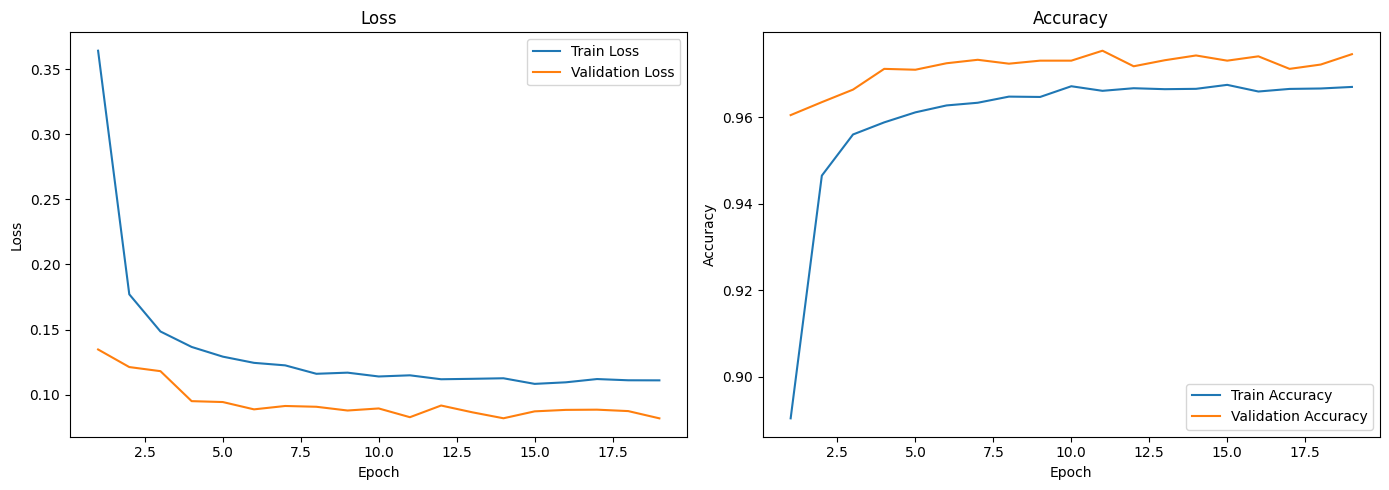

In [ ]:
# Modelo 1.
plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies)

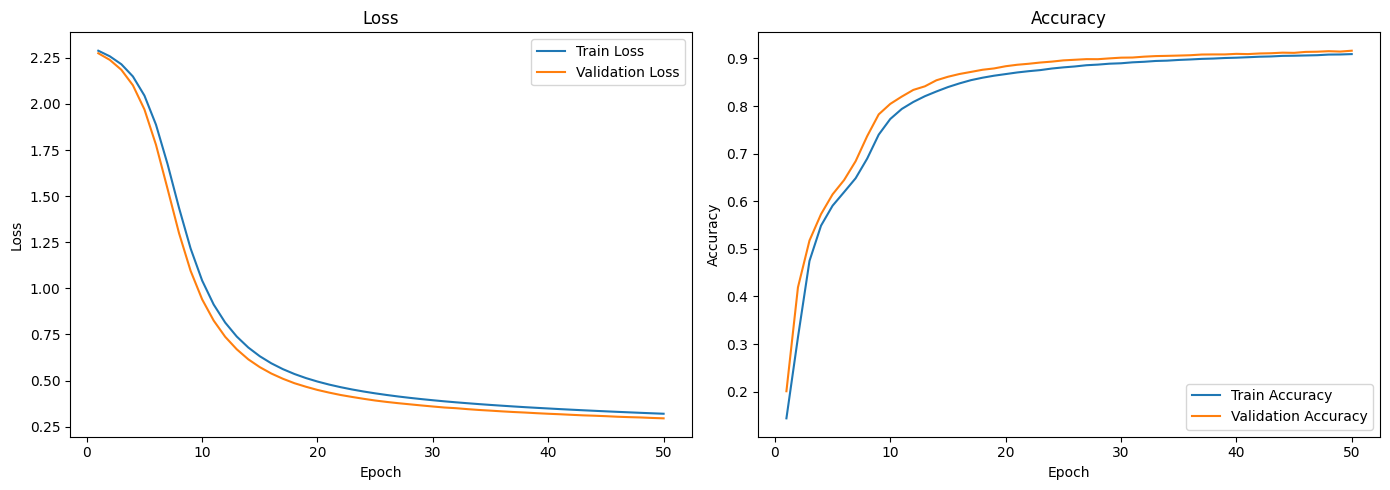

In [61]:
#Modelo 2
plot_learning_curves(train_losses2, val_losses2, train_accuracies2, val_accuracies2)

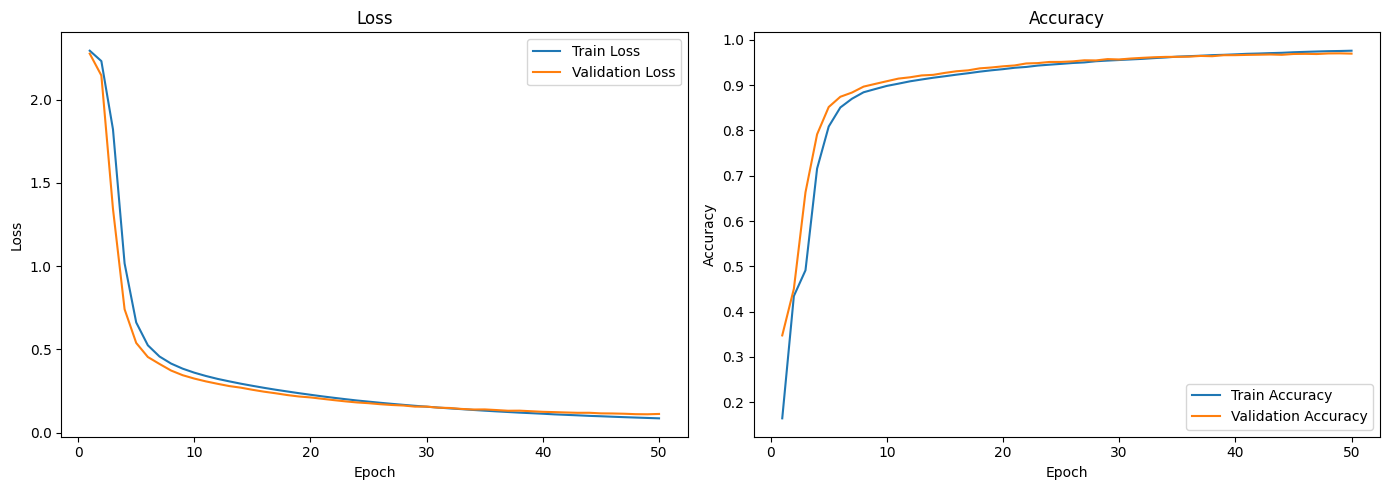

In [62]:
# Modelo 3
plot_learning_curves(train_losses3, val_losses3, train_accuracies3, val_accuracies3)

In [65]:
test_loader = DataLoader(test_data, batch_size=64)

for name, m in [("Modelo 1", model), ("Modelo 2", model2), ("Modelo 3", model3)]:
    m.eval()
    test_loss_batch = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            test_outputs = m(X_batch)
            test_loss_batch += criterion(test_outputs, y_batch).item() * X_batch.size(0)
            _, predicted = torch.max(test_outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    test_loss = test_loss_batch / len(test_loader.dataset)
    test_acc = correct / total
    print(f"{name} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Modelo 1 | Test Loss: 0.0769 | Test Accuracy: 0.9773
Modelo 2 | Test Loss: 0.3025 | Test Accuracy: 0.9128
Modelo 3 | Test Loss: 0.1133 | Test Accuracy: 0.9661
